# North Star Data Cleaning

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Load Datasets

In [15]:
import os

dataset_folder_path = '/content/drive/My Drive/Colab Notebooks/Database_NorthStar_Urban_Mobility/northstar_dataset'

hubs = pd.read_csv(os.path.join(dataset_folder_path, 'hubs.csv'))
customers = pd.read_csv(os.path.join(dataset_folder_path, 'customers.csv'))
drivers = pd.read_csv(os.path.join(dataset_folder_path, 'drivers.csv'))
vehicles = pd.read_csv(os.path.join(dataset_folder_path, 'vehicles.csv'))
orders = pd.read_csv(os.path.join(dataset_folder_path, 'orders.csv'))
deliveries = pd.read_csv(os.path.join(dataset_folder_path, 'deliveries.csv'))
incidents = pd.read_csv(os.path.join(dataset_folder_path, 'incidents.csv'))
complaints = pd.read_csv(os.path.join(dataset_folder_path, 'complaints.csv'))
app_events = pd.read_csv(os.path.join(dataset_folder_path, 'app_events.csv'))

print("All 9 datasets loaded successfully.")
print(f"Hubs: {hubs.shape}")
print(f"Customers: {customers.shape}")
print(f"Drivers: {drivers.shape}")
print(f"Vehicles: {vehicles.shape}")
print(f"Orders: {orders.shape}")
print(f"Deliveries: {deliveries.shape}")
print(f"Incidents: {incidents.shape}")
print(f"Complaints: {complaints.shape}")
print(f"App Events: {app_events.shape}")

All 9 datasets loaded successfully.
Hubs: (8, 5)
Customers: (650, 9)
Drivers: (170, 8)
Vehicles: (120, 8)
Orders: (1250, 11)
Deliveries: (950, 13)
Incidents: (280, 7)
Complaints: (320, 10)
App Events: (640, 10)


#Understand the data structure

In [16]:
print("=== HUBS ===")
hubs.info()
display(hubs.head())

print("\n=== CUSTOMERS ===")
customers.info()
display(customers.describe(include="all").T)

print("\n=== DRIVERS ===")
drivers.info()
display(drivers.describe(include="all").T)

print("\n=== VEHICLES ===")
vehicles.info()
display(vehicles.describe(include="all").T)

print("\n=== ORDERS ===")
orders.info()
display(orders.describe(include="all").T)

print("\n=== DELIVERIES ===")
deliveries.info()
display(deliveries.describe(include="all").T)

print("\n=== INCIDENTS ===")
incidents.info()
display(incidents.describe(include="all").T)

print("\n=== COMPLAINTS ===")
complaints.info()
display(complaints.describe(include="all").T)

print("\n=== APP EVENTS ===")
app_events.info()
display(app_events.describe(include="all").T)

=== HUBS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   hub_id          8 non-null      object
 1   hub_name        8 non-null      object
 2   zone            8 non-null      object
 3   hub_type        8 non-null      object
 4   capacity_score  8 non-null      int64 
dtypes: int64(1), object(4)
memory usage: 452.0+ bytes


,hub_id,hub_name,zone,hub_type,capacity_score
0,H01,North Exchange,North,Dispatch,82
1,H02,South Link,South,Dispatch,78
2,H03,East Dock,East,Warehouse,74
3,H04,West Gate,West,Dispatch,69
4,H05,Central Core,Central,Control,88



=== CUSTOMERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           650 non-null    object 
 1   age                   650 non-null    int64  
 2   home_zone             650 non-null    object 
 3   customer_type         650 non-null    object 
 4   signup_date           650 non-null    object 
 5   loyalty_score         630 non-null    float64
 6   app_engagement_score  650 non-null    float64
 7   preferred_channel     637 non-null    object 
 8   account_status        650 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 45.8+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,650,650,C0650,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,650.0,NaN,NaN,NaN,46.738462,17.449179,18.0,32.0,46.0,62.0,78.0
home_zone,650,16,SOUTH,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_type,650,3,Consumer,476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,650,650,2024-10-21 19:47:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loyalty_score,630.0,NaN,NaN,NaN,59.690635,16.124674,13.1,49.0,59.6,70.45,99.0
app_engagement_score,650.0,NaN,NaN,NaN,58.132308,18.918154,1.0,45.375,59.0,72.0,100.0
preferred_channel,637,4,App,367,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account_status,650,3,Active,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== DRIVERS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   driver_id         170 non-null    object 
 1   base_zone         170 non-null    object 
 2   employment_type   170 non-null    object 
 3   years_experience  170 non-null    int64  
 4   training_score    163 non-null    float64
 5   driver_rating     170 non-null    float64
 6   shift_preference  170 non-null    object 
 7   active_flag       170 non-null    int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 10.8+ KB


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
incident_id,280,280,I0280,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery_id,280,248,DL00578,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incident_type,280,8,ProofMissing,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reported_at,280,280,2024-08-07 06:39:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,280,4,Medium,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolution_status,280,4,Closed,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolved_hours,263.0,NaN,NaN,NaN,12.011407,7.751258,0.0,5.15,11.5,17.95,41.7



=== COMPLAINTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   complaint_id         320 non-null    object 
 1   customer_id          320 non-null    object 
 2   order_id             320 non-null    object 
 3   complaint_type       320 non-null    object 
 4   channel              320 non-null    object 
 5   severity             320 non-null    object 
 6   created_at           320 non-null    object 
 7   status               320 non-null    object 
 8   resolution_days      320 non-null    int64  
 9   compensation_amount  304 non-null    float64
dtypes: float64(1), int64(1), object(8)
memory usage: 25.1+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
complaint_id,320,320,CP0304,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,320,233,C0368,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,320,285,O00795,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
complaint_type,320,7,Delay,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,320,4,App,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,320,3,Medium,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,320,317,2024-11-11 02:46:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,320,4,Resolved,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolution_days,320.0,NaN,NaN,NaN,7.928125,5.214324,1.0,3.75,7.0,11.0,25.0
compensation_amount,304.0,NaN,NaN,NaN,20.257204,15.002195,0.0,8.8225,18.405,29.145,61.85



=== APP EVENTS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   event_id         640 non-null    object
 1   customer_id      640 non-null    object
 2   order_id         496 non-null    object
 3   event_timestamp  640 non-null    object
 4   event_type       640 non-null    object
 5   session_id       640 non-null    object
 6   device_type      640 non-null    object
 7   zone_context     640 non-null    object
 8   api_latency_ms   640 non-null    int64 
 9   success_flag     640 non-null    int64 
dtypes: int64(2), object(8)
memory usage: 50.1+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_id,640,640,AE00624,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,640,412,C0540,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,496,413,O01227,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_timestamp,640,640,2025-06-27 06:15:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,640,8,track_order,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_id,640,637,S67860,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,640,3,Android,315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zone_context,640,16,WEST,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
api_latency_ms,640.0,NaN,NaN,NaN,465.667188,271.634155,60.0,278.75,432.5,609.0,1701.0
success_flag,640.0,NaN,NaN,NaN,0.940625,0.23651,0.0,1.0,1.0,1.0,1.0


#Data quality assessment — missing values

In [17]:
datasets = {
    'hubs': hubs, 'customers': customers, 'drivers': drivers,
    'vehicles': vehicles, 'orders': orders, 'deliveries': deliveries,
    'incidents': incidents, 'complaints': complaints, 'app_events': app_events
}

# Missing Value assessment

for name, df in datasets.items():
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    print(f"\n--- {name} ---")
    if len(missing) > 0:
        display(missing.to_frame("Missing Count"))
    else:
        print("No missing values")


--- hubs ---
No missing values

--- customers ---


,Missing Count
loyalty_score,20
preferred_channel,13



--- drivers ---


,Missing Count
training_score,7



--- vehicles ---


...

,Missing Count
resolved_hours,17



--- complaints ---


,Missing Count
compensation_amount,16



--- app_events ---


,Missing Count
order_id,144


#Data type issues — convert dates

In [19]:
# Convert date/time columns to proper datetime types
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_created_at'] = pd.to_datetime(orders['order_created_at'])
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])
incidents['reported_at'] = pd.to_datetime(incidents['reported_at'])
complaints['created_at'] = pd.to_datetime(complaints['created_at'])
app_events['event_timestamp'] = pd.to_datetime(app_events['event_timestamp'])
vehicles['commission_date'] = pd.to_datetime(vehicles['commission_date'])

print("Date columns converted. Checking dtypes:")
print(f"  customers.signup_date: {customers['signup_date'].dtype}")
print(f"  orders.order_created_at: {orders['order_created_at'].dtype}")
print(f"  deliveries.dispatch_time: {deliveries['dispatch_time'].dtype}")
print(f"  deliveries.delivery_completed_at: {deliveries['delivery_completed_at'].dtype}")
print(f"  incidents.reported_at: {incidents['reported_at'].dtype}")
print(f"  complaints.created_at: {complaints['created_at'].dtype}")
print(f"  app_events.event_timestamp: {app_events['event_timestamp'].dtype}")
print(f"  vehicles.commission_date: {vehicles['commission_date'].dtype}")

Date columns converted. Checking dtypes:
  customers.signup_date: datetime64[ns]
  orders.order_created_at: datetime64[ns]
  deliveries.dispatch_time: datetime64[ns]
  deliveries.delivery_completed_at: datetime64[ns]
  incidents.reported_at: datetime64[ns]
  complaints.created_at: datetime64[ns]
  app_events.event_timestamp: datetime64[ns]
  vehicles.commission_date: datetime64[ns]


#Identify zone name inconsistencies

In [20]:
print("\n--- customers.home_zone ---")
print(customers['home_zone'].value_counts())

print("\n--- drivers.base_zone ---")
print(drivers['base_zone'].value_counts())

print("\n--- vehicles.assigned_zone ---")
print(vehicles['assigned_zone'].value_counts())

print("\n--- orders.pickup_zone ---")
print(orders['pickup_zone'].value_counts())

print("\n--- orders.dropoff_zone ---")
print(orders['dropoff_zone'].value_counts())

print("\n--- app_events.zone_context ---")
print(app_events['zone_context'].value_counts())

print("\nPROBLEM: The same zones appear under different spellings.")
print("For example 'North', 'NORTH', and 'north' all refer to the same zone.")
print("'Central', 'CENTRAL', and 'Ctr' all refer to the same zone.")
print("This must be standardised before any zone-level analysis.")


--- customers.home_zone ---
home_zone
SOUTH        50
RiverSide    49
East         48
WEST         45
CENTRAL      44
West         43
South        42
Riverside    42
EAST         41
North        39
north        39
Airport      35
AIRPORT      34
Ctr          33
NORTH        33
Central      33
Name: count, dtype: int64

--- drivers.base_zone ---
base_zone
South        21
East         14
North        13
Central      12
NORTH        12
north        11
West         10
AIRPORT      10
RiverSide    10
WEST         10
CENTRAL      10
Airport       9
SOUTH         8
EAST          7
Riverside     7
Ctr           6
Name: count, dtype: int64

--- vehicles.assigned_zone ---
assigned_zone
AIRPORT      13
East         12
Riverside    10
CENTRAL      10
North         9
WEST          8
South         8
EAST          8
NORTH         7
SOUTH         6
RiverSide     6
Central       6
Ctr           6
north         5
West          5
Airport       1
Name: count, dtype: int64

--- orders.pickup_zone ---
pick

#Clean zone names

In [21]:
# Standardise all zone name variants to one consistent spelling

zone_mapping = {
    'NORTH': 'North',
    'north': 'North',
    'SOUTH': 'South',
    'EAST': 'East',
    'WEST': 'West',
    'CENTRAL': 'Central',
    'Ctr': 'Central',
    'AIRPORT': 'Airport',
    'RiverSide': 'Riverside'
}

customers['home_zone'] = customers['home_zone'].replace(zone_mapping)
drivers['base_zone'] = drivers['base_zone'].replace(zone_mapping)
vehicles['assigned_zone'] = vehicles['assigned_zone'].replace(zone_mapping)
orders['pickup_zone'] = orders['pickup_zone'].replace(zone_mapping)
orders['dropoff_zone'] = orders['dropoff_zone'].replace(zone_mapping)
app_events['zone_context'] = app_events['zone_context'].replace(zone_mapping)

# Verify
print("AFTER CLEANING — zone values:")
print(f"\ncustomers.home_zone:")
print(customers['home_zone'].value_counts())
print(f"\ndrivers.base_zone:")
print(drivers['base_zone'].value_counts())
print(f"\nvehicles.assigned_zone:")
print(vehicles['assigned_zone'].value_counts())

print("\nAll zone names standardised to 7 consistent values.")

AFTER CLEANING — zone values:

customers.home_zone:
home_zone
North        111
Central      110
South         92
Riverside     91
East          89
West          88
Airport       69
Name: count, dtype: int64

drivers.base_zone:
base_zone
North        36
South        29
Central      28
East         21
West         20
Airport      19
Riverside    17
Name: count, dtype: int64

vehicles.assigned_zone:
assigned_zone
Central      22
North        21
East         20
Riverside    16
Airport      14
South        14
West         13
Name: count, dtype: int64

All zone names standardised to 7 consistent values.


#Handle missing values

In [22]:
# Decision: Leave numerical missing values as NaN to preserve data integrity.
# Only label categorical gaps as 'Unknown'.
# Categorical fields — label the gap honestly
customers['preferred_channel'] = customers['preferred_channel'].fillna('Unknown')
orders['booking_channel'] = orders['booking_channel'].fillna('Unknown')

print("MISSING VALUE HANDLING")
print("=" * 50)
print("Categorical fields filled with 'Unknown':")
print("  - customers.preferred_channel: 13 missing → 'Unknown'")
print("  - orders.booking_channel: 25 missing → 'Unknown'")
print()
print("Numerical fields LEFT AS NaN (data integrity preserved):")
print("  - customers.loyalty_score: 20 missing (score not recorded)")
print("  - drivers.training_score: 7 missing (assessment not completed)")
print("  - vehicles.battery_health_pct: 4 missing (sensor data unavailable)")
print("  - deliveries.delivery_completed_at: 19 missing (delivery not completed)")
print("  - deliveries.customer_rating: 14 missing (customer did not rate)")
print("  - incidents.resolved_hours: 17 missing (incident still unresolved)")
print("  - complaints.compensation_amount: 16 missing (decision not recorded)")
print("  - app_events.order_id: 144 missing (event not linked to an order)")

MISSING VALUE HANDLING
Categorical fields filled with 'Unknown':
  - customers.preferred_channel: 13 missing → 'Unknown'
  - orders.booking_channel: 25 missing → 'Unknown'

Numerical fields LEFT AS NaN (data integrity preserved):
  - customers.loyalty_score: 20 missing (score not recorded)
  - drivers.training_score: 7 missing (assessment not completed)
  - vehicles.battery_health_pct: 4 missing (sensor data unavailable)
  - deliveries.delivery_completed_at: 19 missing (delivery not completed)
  - deliveries.customer_rating: 14 missing (customer did not rate)
  - incidents.resolved_hours: 17 missing (incident still unresolved)
  - complaints.compensation_amount: 16 missing (decision not recorded)
  - app_events.order_id: 144 missing (event not linked to an order)


# Detect delivery time anomalies

In [23]:
# Calculate delivery duration
deliveries['duration_hours'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

# Flag negative durations
deliveries['data_anomaly_flag'] = deliveries['duration_hours'] < 0
negative_count = deliveries['data_anomaly_flag'].sum()

print("DELIVERY TIME ANOMALY DETECTION")
print("=" * 50)
print(f"Deliveries with negative duration (completed BEFORE dispatch): {negative_count}")
print(f"\nStatus breakdown of anomalous records:")
print(deliveries[deliveries['data_anomaly_flag'] == True]['delivery_status'].value_counts())
print(f"\nAll {negative_count} anomalous deliveries are marked 'OnTime' despite having")
print("impossible timestamps. This is evidence of the cross-system data inconsistency")
print("described in the NorthStar case study.")

print(f"\nDuration statistics (excluding anomalies):")
valid_durations = deliveries[deliveries['data_anomaly_flag'] == False]['duration_hours'].dropna()
print(f"  Mean: {valid_durations.mean():.2f} hours")
print(f"  Median: {valid_durations.median():.2f} hours")
print(f"  Min: {valid_durations.min():.2f} hours")
print(f"  Max: {valid_durations.max():.2f} hours")

DELIVERY TIME ANOMALY DETECTION
Deliveries with negative duration (completed BEFORE dispatch): 64

Status breakdown of anomalous records:
delivery_status
OnTime    64
Name: count, dtype: int64

All 64 anomalous deliveries are marked 'OnTime' despite having
impossible timestamps. This is evidence of the cross-system data inconsistency
described in the NorthStar case study.

Duration statistics (excluding anomalies):
  Mean: 10.32 hours
  Median: 7.91 hours
  Min: 0.02 hours
  Max: 43.46 hours


#Feature engineering

In [24]:
# Delivery cost per km
deliveries['cost_per_km'] = deliveries['fuel_or_charge_cost'] / deliveries['route_distance_km']

# Time-based features from orders
orders['order_month'] = orders['order_created_at'].dt.month
orders['order_hour'] = orders['order_created_at'].dt.hour
orders['order_day_of_week'] = orders['order_created_at'].dt.day_name()

# Time-based features from deliveries
deliveries['dispatch_hour'] = deliveries['dispatch_time'].dt.hour
deliveries['dispatch_month'] = deliveries['dispatch_time'].dt.month

# High route override flag
deliveries['high_override_flag'] = deliveries['manual_route_override_count'] >= 3

# Whether an order was fulfilled
fulfilled_order_ids = set(deliveries['order_id'])
orders['has_delivery'] = orders['order_id'].isin(fulfilled_order_ids)

print("NEW FEATURES CREATED")
print("=" * 50)
print("  deliveries.cost_per_km — fuel cost divided by route distance")
print("  orders.order_month — month the order was placed")
print("  orders.order_hour — hour the order was placed")
print("  orders.order_day_of_week — day name the order was placed")
print("  deliveries.dispatch_hour — hour the delivery was dispatched")
print("  deliveries.dispatch_month — month the delivery was dispatched")
print("  deliveries.high_override_flag — True if 3 or more route overrides")
print("  orders.has_delivery — whether the order has a matching delivery record")

NEW FEATURES CREATED
  deliveries.cost_per_km — fuel cost divided by route distance
  orders.order_month — month the order was placed
  orders.order_hour — hour the order was placed
  orders.order_day_of_week — day name the order was placed
  deliveries.dispatch_hour — hour the delivery was dispatched
  deliveries.dispatch_month — month the delivery was dispatched
  deliveries.high_override_flag — True if 3 or more route overrides
  orders.has_delivery — whether the order has a matching delivery record


#Identify unfulfilled orders

In [25]:
unfulfilled = orders[orders['has_delivery'] == False]

print("UNFULFILLED ORDERS ANALYSIS")
print("=" * 50)
print(f"Total orders: {len(orders)}")
print(f"Orders with delivery: {orders['has_delivery'].sum()}")
print(f"Orders WITHOUT delivery: {len(unfulfilled)} ({len(unfulfilled)/len(orders)*100:.1f}%)")

print(f"\nBy service type:")
print(unfulfilled['service_type'].value_counts())

print(f"\nBy pickup zone:")
print(unfulfilled['pickup_zone'].value_counts())

print(f"\nBy priority level:")
print(unfulfilled['priority_level'].value_counts())

UNFULFILLED ORDERS ANALYSIS
Total orders: 1250
Orders with delivery: 950
Orders WITHOUT delivery: 300 (24.0%)

By service type:
service_type
Passenger    79
Parcel       78
Retail       73
Business     39
Medical      31
Name: count, dtype: int64

By pickup zone:
pickup_zone
Central      64
East         51
South        42
West         41
North        39
Riverside    32
Airport      31
Name: count, dtype: int64

By priority level:
priority_level
Medium      117
Low          89
High         77
Critical     17
Name: count, dtype: int64


#Duplicate rows

In [26]:
print("DUPLICATE CHECK (after zone standardisation)")
print("=" * 50)

# Full row duplicates
for name, df in datasets.items():
    dupes = df.duplicated().sum()
    if dupes > 0:
        print(f"{name}: {dupes} fully duplicated rows")

# ID-level duplicates (same ID appearing more than once)
id_columns = {
    'hubs': 'hub_id', 'customers': 'customer_id', 'drivers': 'driver_id',
    'vehicles': 'vehicle_id', 'orders': 'order_id', 'deliveries': 'delivery_id',
    'incidents': 'incident_id', 'complaints': 'complaint_id', 'app_events': 'event_id'
}

for name, id_col in id_columns.items():
    df = datasets[name]
    id_dupes = df[id_col].duplicated().sum()
    if id_dupes > 0:
        print(f"{name}: {id_dupes} duplicate {id_col} values")

if all(df.duplicated().sum() == 0 for df in datasets.values()):
    print("No full row duplicates found in any dataset.")
if all(datasets[name][id_col].duplicated().sum() == 0 for name, id_col in id_columns.items()):
    print("No duplicate IDs found in any dataset.")

DUPLICATE CHECK (after zone standardisation)
No full row duplicates found in any dataset.
No duplicate IDs found in any dataset.


#Quick business overview



In [27]:
summary = {
    "Total Customers": len(customers),
    "Total Orders": len(orders),
    "Unfulfilled Orders (%)": round(len(unfulfilled) / len(orders) * 100, 2),
    "Total Deliveries": len(deliveries),
    "On-Time Deliveries (%)": round((deliveries['delivery_status'] == 'OnTime').mean() * 100, 2),
    "Delayed Deliveries (%)": round((deliveries['delivery_status'] == 'Delayed').mean() * 100, 2),
    "Failed Deliveries (%)": round((deliveries['delivery_status'] == 'Failed').mean() * 100, 2),
    "Total Incidents": len(incidents),
    "Total Complaints": len(complaints),
    "Data Anomalies (negative duration)": negative_count,
}
display(pd.DataFrame(summary, index=["Value"]).T)

,Value
Total Customers,650.00
Total Orders,1250.00
Unfulfilled Orders (%),24.00
Total Deliveries,950.00
On-Time Deliveries (%),64.84
Delayed Deliveries (%),21.26
Failed Deliveries (%),13.89
Total Incidents,280.00
Total Complaints,320.00
Data Anomalies (negative duration),64.00


#Visual overview — delivery status

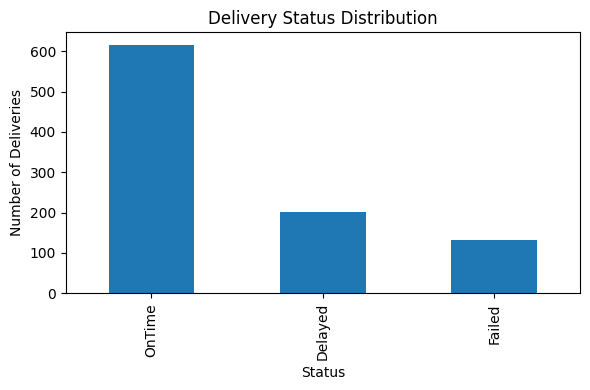

In [28]:
plt.figure(figsize=(6, 4))
deliveries['delivery_status'].value_counts().plot(kind='bar')
plt.title('Delivery Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Deliveries')
plt.tight_layout()
plt.show()

#Visual overview — complaint types

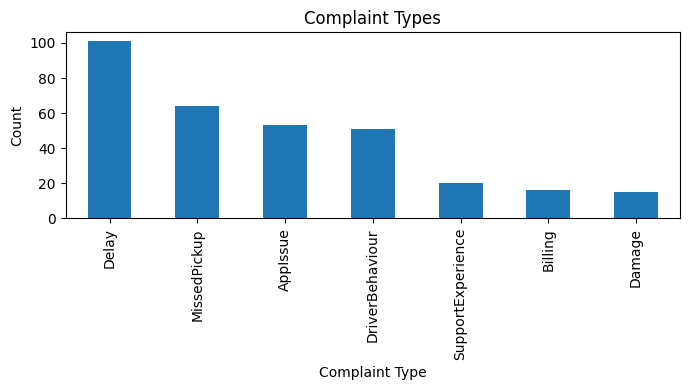

In [29]:
plt.figure(figsize=(7, 4))
complaints['complaint_type'].value_counts().plot(kind='bar')
plt.title('Complaint Types')
plt.xlabel('Complaint Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#Visual overview — incident types

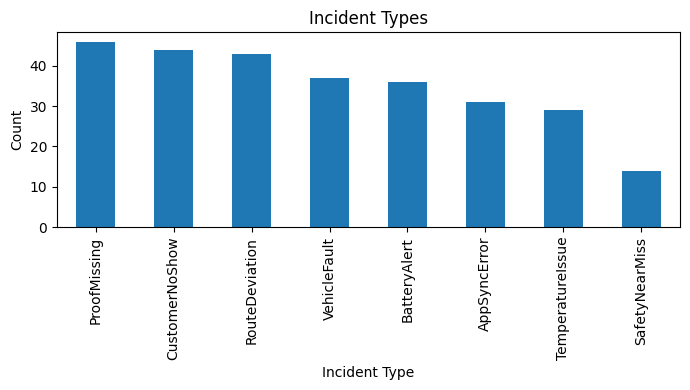

In [30]:
plt.figure(figsize=(7, 4))
incidents['incident_type'].value_counts().plot(kind='bar')
plt.title('Incident Types')
plt.xlabel('Incident Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#Cleaning summary and business insights

In [31]:
insights = [
    "Zone names were inconsistent across all files (16 variants for 7 zones) — now standardised.",
    f"{negative_count} deliveries have impossible timestamps (completed before dispatch) — all marked 'OnTime', suggesting cross-system data inconsistency.",
    f"{len(unfulfilled)} orders ({len(unfulfilled)/len(orders)*100:.1f}%) have no delivery record — nearly a quarter of orders are unfulfilled.",
    f"Only {(deliveries['delivery_status'] == 'OnTime').mean()*100:.1f}% of deliveries are on time. {(deliveries['delivery_status'] == 'Failed').mean()*100:.1f}% failed completely.",
    "Delay is the most common complaint type, followed by MissedPickup.",
    f"{len(incidents)} incidents recorded across {incidents['delivery_id'].nunique()} deliveries — 26% of deliveries have at least one incident.",
    "Data quality checks revealed missing values across multiple files. Numerical gaps were preserved as NaN to maintain data integrity."
]

print("CLEANING SUMMARY — KEY FINDINGS")
print("=" * 50)
for i, item in enumerate(insights, start=1):
    print(f"{i}. {item}")

CLEANING SUMMARY — KEY FINDINGS
1. Zone names were inconsistent across all files (16 variants for 7 zones) — now standardised.
2. 64 deliveries have impossible timestamps (completed before dispatch) — all marked 'OnTime', suggesting cross-system data inconsistency.
3. 300 orders (24.0%) have no delivery record — nearly a quarter of orders are unfulfilled.
4. Only 64.8% of deliveries are on time. 13.9% failed completely.
5. Delay is the most common complaint type, followed by MissedPickup.
6. 280 incidents recorded across 248 deliveries — 26% of deliveries have at least one incident.
7. Data quality checks revealed missing values across multiple files. Numerical gaps were preserved as NaN to maintain data integrity.


#Save cleaned datasets

In [32]:
cleaned_path = '/content/drive/My Drive/Colab Notebooks/Database_NorthStar_Urban_Mobility/northstar_dataset/cleaned'
os.makedirs(cleaned_path, exist_ok=True)

hubs.to_csv(os.path.join(cleaned_path, 'clean_hubs.csv'), index=False)
customers.to_csv(os.path.join(cleaned_path, 'clean_customers.csv'), index=False)
drivers.to_csv(os.path.join(cleaned_path, 'clean_drivers.csv'), index=False)
vehicles.to_csv(os.path.join(cleaned_path, 'clean_vehicles.csv'), index=False)
orders.to_csv(os.path.join(cleaned_path, 'clean_orders.csv'), index=False)
deliveries.to_csv(os.path.join(cleaned_path, 'clean_deliveries.csv'), index=False)
incidents.to_csv(os.path.join(cleaned_path, 'clean_incidents.csv'), index=False)
complaints.to_csv(os.path.join(cleaned_path, 'clean_complaints.csv'), index=False)
app_events.to_csv(os.path.join(cleaned_path, 'clean_app_events.csv'), index=False)

print(f"All 9 cleaned datasets saved to: {cleaned_path}")
print("These will be loaded in all subsequent notebooks.")

All 9 cleaned datasets saved to: /content/drive/My Drive/Colab Notebooks/Database_NorthStar_Urban_Mobility/northstar_dataset/cleaned
These will be loaded in all subsequent notebooks.
